In [534]:
import numpy as np

import sklearn
from sklearn.model_selection import train_test_split
from sklearn import linear_model

import matplotlib
import matplotlib.pyplot as plt


In [535]:
# Independent data
nsamp = 100
xdat = np.random.uniform(-2,7,nsamp)

# Data:
beta = np.array([4.342, -0.7, 2.7])
y0 = beta[0] + beta[1] * np.exp(-xdat/2) + beta[2] * np.exp(-xdat)
wstd = 0.2 # noise
ydat = y0 + np.random.normal(0,wstd,nsamp)

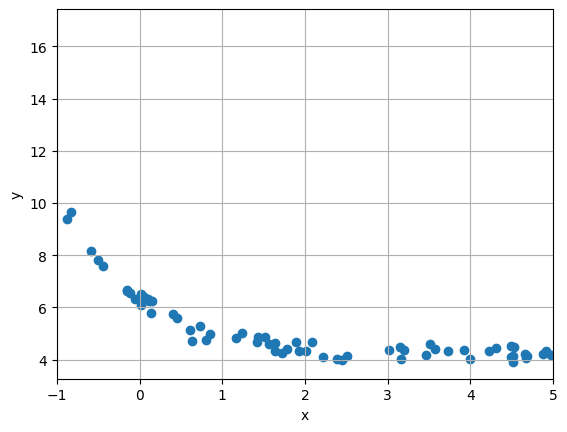

In [536]:
plt.scatter(xdat,ydat)
plt.xlim([-1,5])
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

In [537]:
# Split
utr, uts, ytr, yts = train_test_split(xdat, ydat, test_size=0.5)

In [538]:
utr.shape

(50,)

In [539]:
ytr.shape

(50,)

## using sklearn:

In [540]:
# Fit:
MSE = []
dtest = np.arange(1,12)

for d in dtest:
    # model using train data:
    Xtr = np.exp(utr[:, None] * np.arange(1, d+1)/(-d))
    model = linear_model.LinearRegression()
    model.fit(Xtr, ytr)

    # predict with test data:
    Xts = np.exp(uts[:, None] * np.arange(1, d+1)/(-d))
    yhat = model.predict(Xts)

    # find mse:
    MSE.append(np.mean((yhat - yts)**2))

    print("intercept for d = {0:2d} is {1:f}".format(d, model.intercept_), " coefficients: ", *model.coef_)

print(MSE)

intercept for d =  1 is 4.217158  coefficients:  2.2251909910441037
intercept for d =  2 is 4.295118  coefficients:  -0.5430792205116813 2.6355237938875997
intercept for d =  3 is 4.287723  coefficients:  -0.08503454628890465 -0.640106513647524 2.8201130611898866
intercept for d =  4 is 4.219591  coefficients:  0.5330649203414816 -1.717711592608408 1.0132851593471595 2.337064119969514
intercept for d =  5 is -0.379268  coefficients:  43.0813680817615 -147.41994772553477 233.6980467986721 -174.56365161474534 51.958278503078986
intercept for d =  6 is 24.445170  coefficients:  -220.83528582583182 961.066299713625 -2126.7189662785295 2525.607778680992 -1531.4482802684588 374.2665073742521
intercept for d =  7 is -86.565215  coefficients:  1041.4452710378337 -5034.55015374183 13276.554971476009 -20582.659967278705 18723.618342917485 -9244.274882518652 1912.8252304028197
intercept for d =  8 is -2370.262495  coefficients:  27489.60340019055 -136741.05520246187 381639.50269399694 -653590.208

## using linalg:

In [541]:
MSE_np = []
for d_np in dtest:
    # model:
    Xtr = np.exp(utr[:, None] * np.arange(d_np+1)/(-d_np))
    out = np.linalg.lstsq(Xtr, ytr, rcond=None)

    # predict:
    Xts = np.exp(uts[:, None] * np.arange(d_np+1)/(-d_np))
    yhat = Xts @ out[0]

    MSE_np.append(np.mean((yhat - yts)**2))

    print("intercept for d = {0:2d} is {1:f}".format(d_np, out[0][0]), " coefficients: ", *out[0][1:] )

print(MSE_np)


intercept for d =  1 is 4.217158  coefficients:  2.2251909910441032
intercept for d =  2 is 4.295118  coefficients:  -0.5430792205116806 2.6355237938875975
intercept for d =  3 is 4.287723  coefficients:  -0.08503454628890839 -0.6401065136475259 2.820113061189878
intercept for d =  4 is 4.219591  coefficients:  0.5330649203414031 -1.7177115926081996 1.0132851593469443 2.3370641199695923
intercept for d =  5 is -0.379268  coefficients:  43.08136808175876 -147.41994772552414 233.69804679865504 -174.5636516147331 51.95827850307566
intercept for d =  6 is 24.445170  coefficients:  -220.83528582403795 961.066299706434 -2126.718966263744 2525.607778664512 -1531.4482802589914 374.2665073720558
intercept for d =  7 is -86.565215  coefficients:  1041.4452711864283 -5034.550154410977 13276.554973108065 -20582.659969609173 18723.618344867908 -9244.274883405717 1912.8252305721867
intercept for d =  8 is -2370.262493  coefficients:  27489.603385024337 -136741.05512577083 381639.5024761843 -653590.2

## Compare:

In [542]:
np.sum((np.array(MSE) - np.array(MSE_np))**2)

np.float64(7.229163117569303e-06)

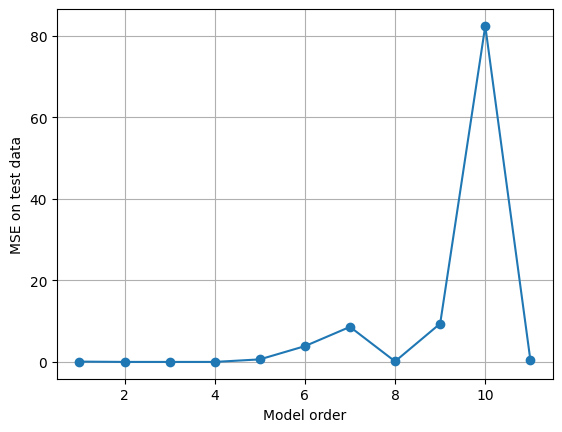

In [543]:
plt.plot(dtest, MSE, 'o-')
plt.xlabel('Model order')
plt.ylabel('MSE on test data')
plt.grid()

In [544]:
print(MSE.index(min(MSE)) + 1)

2


## Matrix multiplication check:

In [545]:
A = np.arange(-5,6,2).reshape(2,3)
b = np.array([[2],[-9],[7]]).reshape(3,)
print(A)
print(b)

[[-5 -3 -1]
 [ 1  3  5]]
[ 2 -9  7]


In [546]:
A@b

array([10, 10])